# Week 9 Practical - Production ML Pipelines & CI/CD
### Turn a notebook that trains a model into a system that keeps working

**Your mission.** Build an automated, re-runnable pipeline: ingest -> validate ->
train -> evaluate -> conditional deploy, with a metric gate, an experiment log, tests,
and a CI workflow. By Friday you ship the pipeline plus a one-page CI/CD design note.

You are given `mlpipe.py` with function stubs, a `data/` folder (a golden `eval.csv`
and several training batches), and a `test_pipeline.py` to make pass.

> The two things that make a pipeline safe: a **validation gate** that stops bad data,
> and a **promotion gate** that never lets a worse model reach production. Fill every
> `# TODO`, then get `pytest` green.

## Part 0 - Setup

In [1]:
import os, json, inspect, subprocess, shutil, warnings
warnings.filterwarnings("ignore")
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import mlpipe
sns.set_theme(style="whitegrid")
if not os.path.exists("data/eval.csv"):
    subprocess.run(["python", "gen_data.py"], check=True)
print("ready")

ready


## Part 1 - The validation gate
Open `mlpipe.py` and complete `validate(df, schema)`. It must return `(ok, issues)` and
check: required columns present, null rate under the limit, numeric ranges, and allowed
categories for `shift` and the target. Then run it on a clean and an invalid batch.

*Hint: build a list of issue strings; `ok` is `len(issues) == 0`.*

In [3]:
import mlpipe

df_clean = mlpipe.ingest("data/train.csv")
ok, issues = mlpipe.validate(df_clean, mlpipe.SCHEMA)

print("Clean batch:")
print("ok =", ok)
print("issues =", issues)

Clean batch:
ok = True
issues = []


In [4]:
df_invalid = mlpipe.ingest("data/train_invalid.csv")
ok, issues = mlpipe.validate(df_invalid, mlpipe.SCHEMA)

print("Invalid batch:")
print("ok =", ok)
print("issues =", issues)

Invalid batch:
ok = False
issues = ['avg_vibration out of range [0, 20]', "shift has unexpected values: ['twilight']"]


## Part 2 - Train and evaluate on the golden set
Complete `train(df, seed)` and `evaluate(model, df)` in `mlpipe.py`. Train on
`data/train.csv` and evaluate on `data/eval.csv`. Every run must be judged on this same
golden set.

*Hint: a scikit-learn `Pipeline` (ColumnTransformer + LogisticRegression); return AUC,
accuracy, F1.*

In [6]:
import mlpipe

train_df = mlpipe.ingest("data/train.csv")
eval_df = mlpipe.ingest("data/eval.csv")

model = mlpipe.train(train_df, seed=9)

metrics = mlpipe.evaluate(model, eval_df)

print(metrics)

{'auc': 0.8793, 'accuracy': 0.8, 'f1': 0.7727}


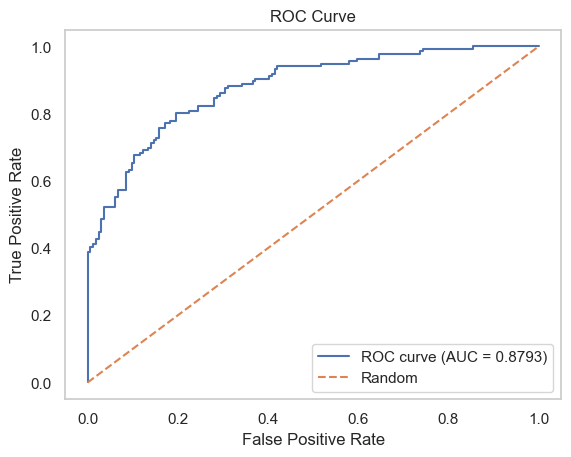

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_true = eval_df["high_defect"]
proba = model.predict_proba(
    eval_df[mlpipe.NUMERIC + mlpipe.CATEGORICAL]
)[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, proba)

auc = roc_auc_score(y_true, proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## Part 3 - The promotion gate
Complete `promote(challenger, champion, threshold)`. A challenger is promoted only if
it clears the threshold **and** beats the champion; otherwise it is rejected. Show it
accepting a better model and rejecting a worse one.

*Hint: two conditions, two reject reasons, one promote.*

In [9]:
champion = {"auc": 0.8793}
challenger = {"auc": 0.8808}
ok, reason = mlpipe.promote(
    challenger,
    champion,
    threshold=0.70
)

print(ok, reason)

promote clears threshold and beats champion


In [10]:
challenger = { "auc": 0.8589}
ok, reason = mlpipe.promote(
    challenger,
    champion,
    threshold=0.70
)

print(ok, reason)

reject AUC 0.8589 does not beat champion 0.8793


In [11]:
challenger = {"auc": 0.65}
ok, reason = mlpipe.promote(
    challenger,
    champion,
    threshold=0.70
)

print(ok, reason)

reject AUC 0.65 below threshold 0.7


## Part 4 - Run the pipeline across four scenarios
Complete `run_pipeline(train_path, eval_path, ...)` so it ingests, validates (and
blocks bad data), trains, evaluates, registers a version, applies the promotion gate,
and appends to `runs.csv`. Then run it on: baseline, invalid, drifted, improved. Track
the champion.

*Hint: return a record dict; on a validation failure set decision to `blocked` and
return early.*

In [14]:
import mlpipe

scenarios = [
    ("baseline", "data/train.csv"),
    ("invalid", "data/train_invalid.csv"),
    ("drifted", "data/train_drifted.csv"),
    ("improved", "data/train_v2.csv"),
]

for name, path in scenarios:
    result = mlpipe.run_pipeline(
        train_path=path,
        eval_path="data/eval.csv",
        registry_dir="registry",
        runs_csv="runs.csv",
        seed=9,
        threshold=0.70
    )

    champion = mlpipe.load_champion("registry")

    print(
        f"{name}: "
        f"decision={result['decision']} | "
        f"auc={result['auc']} | "
        f"champion={champion['version'] if champion else None}"
    )

baseline: decision=promote | auc=0.8793 | champion=1
invalid: decision=blocked | auc=None | champion=1
drifted: decision=reject | auc=0.8589 | champion=1
improved: decision=promote | auc=0.8808 | champion=3


## Part 5 - Visualise and log
Read `runs.csv` into a table and plot each run's AUC coloured by decision, with the
threshold line. *(build the chart here)*

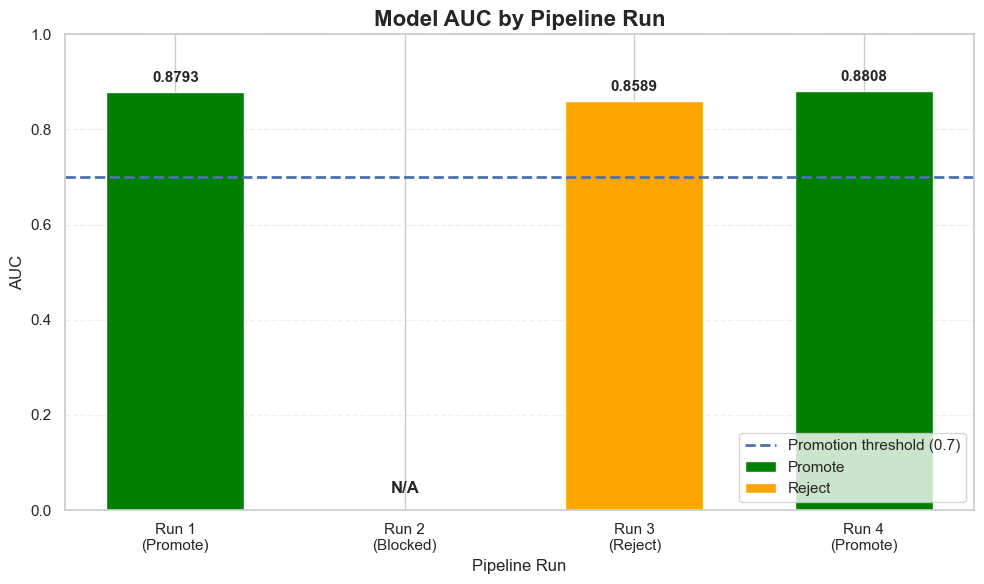

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
runs = pd.read_csv("runs.csv")
runs["Run"] = [f"Run {i + 1}" for i in range(len(runs))]

runs["auc"] = pd.to_numeric(runs["auc"], errors="coerce")

decision_colors = {
    "promote": "green",
    "reject": "orange",
    "blocked": "steelblue"
}

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in runs.iterrows():

    auc = row["auc"]
    decision = row["decision"]

    # Blocked runs have no AUC
    if pd.isna(auc):
        ax.text(
            i,
            0.03,
            "N/A",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )
        continue

    ax.bar(
        i,
        auc,
        width=0.6,
        color=decision_colors.get(decision, "gray"),
        label=decision.capitalize()
    )

    ax.text(
        i,
        auc + 0.015,
        f"{auc:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

threshold = 0.70

ax.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Promotion threshold ({threshold})"
)

ax.set_xticks(range(len(runs)))
ax.set_xticklabels(
    [
        f"Run {i + 1}\n({row['decision'].capitalize()})"
        for i, row in runs.iterrows()
    ]
)

ax.set_xlabel("Pipeline Run", fontsize=12)
ax.set_ylabel("AUC", fontsize=12)
ax.set_title(
    "Model AUC by Pipeline Run",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylim(0, 1)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

handles, labels = ax.get_legend_handles_labels()

unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    loc="lower right"
)

plt.tight_layout()
plt.show()

## Part 6 - Tests and CI
Get the suite green, then read the CI workflow.

*Hint: from a terminal, `pytest -q`. Fix `mlpipe.py` until all tests pass.*

In [20]:
import importlib
import mlpipe

importlib.reload(mlpipe)

<module 'mlpipe' from 'C:\\Users\\Naveenkumar.s\\Downloads\\Pipelines\\mlpipe.py'>

In [21]:
import inspect

print(inspect.signature(mlpipe.run_pipeline))

(train_path: 'str', eval_path: 'str', registry_dir: 'str', runs_csv: 'str', seed: 'int' = 9, threshold: 'float' = 0.8, run_id: 'str | None' = None) -> 'dict'


In [22]:
import subprocess

result = subprocess.run(
    ["python", "-m", "pytest", "-q"],
    capture_output=True,
    text=True
)

print(result.stdout)

...........                                                              [100%]
11 passed in 2.32s



## Part 7 - The CI/CD design note
CI/CD Design Note — Production ML Pipeline

Pipeline:
Ingest → Validate → Train → Evaluate → Register → Promote → Champion

Validation Gate:
Blocks malformed data using schema, null-rate, range, and category checks before training.

Promotion Gate:
Promotes only when AUC ≥ threshold AND AUC > current champion. Otherwise, the champion is retained.

Experiment Tracking:
Logs every run in runs.csv and versions models in the registry, maintaining a clear champion history.

CI:
GitHub Actions installs pinned dependencies, runs 11 automated tests, and executes the pipeline on code changes.

CD & Rollback:
Only a promoted champion is deployed. Rollback is achieved by re-pointing production to the previous champion version.

Reproducibility:
Guaranteed through fixed seeds, pinned dependencies, versioned artifacts, and a fixed golden evaluation set.

Key Outcome

Bad data is blocked. Inferior models are rejected. Better models are promoted safely — with every decision tracked and reproducible.